# Assessing Fire Radiative Power (FRP) in Amazon Wildfire Events to Support Forest Management and Climate Assessments.

Production date: 08-05-2026

Produced by: Vitor Miranda & André Brito (CoLAB +ATLANTIC)

## 🌍 Use case: Fire Radiative Power events consistency assessment

## ❓ Quality assessment question
* **Are the Fire Radiative Power (FRP) and Active Fire (AF) pixel counts from the C3S Sentinel-3 dataset spatially and temporally consistent with those reported in peer-reviewed literature over the Amazon Basin?**

{admonition}
:class: note

In this quality assessment, we will assess the Fire Radiative Power (FRP) between 2020-2025 (i.e. Jan-2020 until Feb-2025) derived from satellite observations from the Climate Data Store (CDS) of the Copernicus Climate Change Service (C3S). The grid-scale product of this dataset, including information on Fire Radiative Power (FRP, MW) and Active Fire (AF, counts), will be used to quantify the intensity and spatial distribution of biomass burning 
events across the Area of Interest (AoI), with the aim of evaluating the fitness of 
the C3S dataset for applications in forest management, carbon budget monitoring, and 
regional climate assessment.

The analysis will focus on the 2020–2025 period, with particular attention to the seasonal and spatial variability of Fire Radiative Power (FRP) across the Amazon basin, which will allow for a clearer understanding of the magnitude of fire events during this timeframe. Although the C3S FRP product provides global coverage, recent “State of Wildfires” reports (e.g. [[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html) and [[2]](https://essd.copernicus.org/preprints/essd-2025-483/)) have consistently identified the Amazon Basin as one of the regions showing the most pronounced fire anomalies worldwide. The moist tropical forests of South America, exhibited some of the highest departures from long-term averages, including exceptional increases in burned area, FRP, and associated carbon emissions. The previous studies highlight that Amazonia has transitioned into a major hotspot of high-intensity fires, where extreme events (often linked to land-use pressures) have far-reaching impacts on carbon budgets, ecosystem resilience, and regional climate. Focusing on the Amazon Basin therefore allows the global C3S product to be applied to a region where fire intensity is changing rapidly and where improvements in understanding FRP dynamics are particularly urgent and societally relevant.

The results provided here will be compared with the findings reported in the previous referenced studies, i.e. [[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html) and [[2]](https://essd.copernicus.org/preprints/essd-2025-483/), allowing for an evaluation of the dataset’s consistency and performance relative to previously documented fire patterns over the region.

The main question this quality assessment expects to answer is:

1) Is the C3S product able to reproduce the patterns and magnitudes of FRP and AF dynamics reported in the cited studies?

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* The C3S FRP dataset shows spatially coherent seasonal patterns of fire activity 
across the Amazon Basin for 2020–2025, with the highest activity consistently 
concentrated in southeastern Amazonia and Bolivia during the June-July-August (JJA) and September-October-November (SON) seasons, while the analysis also included December–January–February (DJF) and March–April–May (MAM).

* Annual AF pixel counts increased substantially over the period in 
both regions: from 12,120 to 24,040 fire pixels in Amazonas (2.0x), and from 
57,070 to 126,113 fire pixels in Bolivia (2.7x). The 95th percentile FRP peaked 
at 30.5 MW in Amazonas (2024) and 44.0 MW in Bolivia (2023), indicating a trend 
of increasing fire intensity over the period.

* Both datasets i.e. C3S and the State of Wildfires reference (Kelley et al., 2025),
consistently identify 2022 and 2024 as years of elevated fire activity in Amazonas 
and Bolivia, supporting the temporal consistency of the C3S dataset despite 
differences in absolute magnitude (~10–20x higher AF pixel counts in C3S due to 
finer spatial resolution).

* The short length of the C3S time series (5 years, 2020–2025) precludes the 
computation of climatologically meaningful standardised anomalies, representing 
a key limitation of the dataset at its current stage.

* Observation quality flags confirm that atmospheric conditions (e.g. cloud cover) 
affect a higher fraction of pixels during DJF and MAM — the wet season — 
particularly over the western Amazon and Andes foothills. During JJA and SON, 
atmospheric obstruction is markedly reduced, coinciding with the dry season when 
fire activity is highest. This supports the reliability of the FRP and AF 
retrievals during the fire-active seasons. Surface condition flags are largely 
static and reflect permanent features such as water bodies, with no meaningful 
temporal variability.
```

## 📋 Methodology

* **[](section-1) Spatial Analysis**  
Satellite-derived FRP and AF pixel datasets from 2020 to 2025 were used to assess seasonal spatial patterns of fire activity across Amazonia and adjacent regions. Seasonal aggregations were performed for DJF, MAM, JJA, and SON seasons, to compare fire activity spatially within and across years. Spatial comparison was based on seasonal absolute AF counts. Standardised anomaly analysis were considered but not performed, as the 5-year length of the C3S time series is insufficient to derive climatologically meaningful anomalies.

* **[](section-2) Temporal Analysis**  
Time series of AF counts and FRP values were computed to identify consistent fire signals. Cross-dataset comparisons examined temporal correlation and magnitude differences, against state-of-wildfires dataset [[2]](https://essd.copernicus.org/preprints/essd-2025-483/) reference. Specific regions such as Bolivia, and Amazonas state were considered.

* **[](section-3) Daily Temporal Peak**  
High-temporal-resolution daily fire pixel counts were analyzed to identify peak fire days within targeted subregion such as Western Amazonia. Daily aggregation across spatial dimensions (latitude, longitude) yielded time series of daily AF pixel counts, from which peak days and their ranks were extracted. Comparisons to referenced state-of-wildfires dataset [[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html) were made.


## 📈 Analysis and results

(section-1)=
### 1. Data Overview, download and Area of Interest (AoI) definition

#### Import all the libraries/packages

We will be working with data in NetCDF format. To best handle this data we will use libraries for working with multidimensional arrays, in particular Xarray. We will also need libraries for plotting and viewing data, in this case we will use Matplotlib and Cartopy.

In [ ]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
from rasterio import features
import xarray as xr
from c3s_eqc_automatic_quality_control import download, plot, utils
import cartopy.feature as cfeature
from shapely.geometry import Polygon
import matplotlib.dates as mdates
from shapely.geometry import box
from matplotlib.colors import ListedColormap
import warnings
import matplotlib.image as mpimg
import requests, zipfile, io
from matplotlib.patches import Patch
from IPython.display import Markdown, display
import matplotlib.colors as mcolors
import matplotlib.cm as cm

plt.style.use("seaborn-v0_8-notebook")

/home/andre/.conda/envs/air4health_user/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Search for data

The dataset used in this quality assessment is the *Fire radiative power and active fire pixels from 2020 to present derived from satellite observations*, available on the CDS ([cds.climate.copernicus.eu](http://cds.climate.copernicus.eu)). This dataset provides global information on the timing, location and intensity of active fires burning on Earth's surface during satellite overpasses, at both grid and point scale, following the Global Climate Observing System (GCOS) convention. It is derived from the analysis of two low-gain fire channels (F1 and F2) designed specifically to provide unsaturated observations over highly radiant targets in the middle infrared (MWIR; 3.74 µm) and longwave infrared (LWIR; 10.8 µm) wavebands, from the Sea and Land Surface Temperature Radiometer (SLSTR) instrument aboard the Sentinel-3 satellites.

Two versions are available (1.0 and 1.2); this assessment uses version 1.2, which covers the 2020–2025 period. The spatial resolution varies by temporal aggregation: 0.25° for the monthly gridded product and 0.1° for the daily gridded product. The vertical resolution corresponds to the surface (single level).

The gridded monthly product was selected for the spatial analysis, using the following parameters:

* **dataset:** satellite-fire-radiative-power
* **variable:** all
* **product_type:** gridded
* **time_aggregation:** month
* **horizontal_aggregation:** 0_25_degree_x_0_25_degree
* **satellite:** sentinel_3a, sentinel_3b
* **observation_time:** day, night
* **year:** 2020–2025
* **month:** 01–12
* **day:** 01
* **version:** 1_2

(section-2)=
### 2. Download AoI and Monthly data

Three specific Areas of Interest (AoI) were selected here, i.e. Amazon basin, Amazonas state and Bolívia. Following the references: [[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html) and [[2]](https://essd.copernicus.org/preprints/essd-2025-483/).

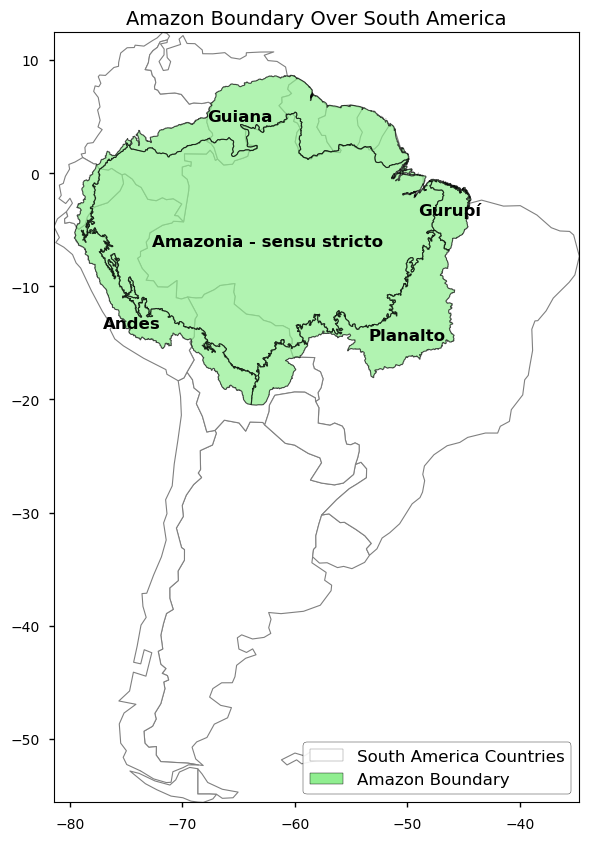

Figure 1.4.1.1. Amazon Boundary Over South America.

In [2]:
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. Download & load Natural Earth countries
# ---------------------------------------------------------
ne_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
r = requests.get(ne_url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("ne_110m_admin_0_countries")

countries_gdf = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
countries_gdf = countries_gdf.to_crs("EPSG:4326")

# ---------------------------------------------------------
# 2. Filter South America only
# ---------------------------------------------------------
sa = countries_gdf[countries_gdf["CONTINENT"] == "South America"]

# ---------------------------------------------------------
# 3. Load the Amazon shapefile
# ---------------------------------------------------------
amaz_url = "https://forobs.jrc.ec.europa.eu/static/amazon/amazonia_boundary_proposal_Eva_2005.zip"
amazon = gpd.read_file(amaz_url).to_crs("EPSG:4326")

# ---------------------------------------------------------
# 4. Plot South America + Amazon
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# South America countries
sa.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.8)

# Amazon region
amazon.plot(ax=ax, color="lightgreen", edgecolor="black", linewidth=0.8, alpha=0.7)

# Label Amazon subregions
# Compute representative points (base label positions)
unique = amazon.drop_duplicates(subset="name")
unique["x"] = unique.geometry.representative_point().x
unique["y"] = unique.geometry.representative_point().y
# Manually adjust label positions (dx, dy) offsets
manual_offsets = {
    "Andes": (2.5, -5.0),                  # adjust here
    "Guiana": (0.0, 0.0),                 # adjust here
    "Planalto": (-1.0, -2.0),               # adjust here
    "Amazonia - senso strictu": (0.0, 0.0),  # adjust here
    "Gurupi": (0.0, 0.0),                 # adjust here
}


for _, row in unique.iterrows():
    name = row["name"]
    x = row["x"]
    y = row["y"]

    # apply your (dx, dy) offsets
    dx, dy = manual_offsets.get(name, (0, 0))

    ax.text(
        x + dx,
        y + dy,
        name,
        ha="center",
        fontsize=12,
        color="black",
        weight="bold"
    )

# ---------------------------------------------------------
# 4b. Legend
# ---------------------------------------------------------
legend_elements = [
    Patch(facecolor="white", edgecolor="gray", label="South America Countries"),
    Patch(facecolor="lightgreen", edgecolor="black", label="Amazon Boundary"),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=12,
    frameon=True,
    framealpha=0.9,
    edgecolor="black"
)

# ---------------------------------------------------------
# 5. Limit axis to South America extent
# ---------------------------------------------------------
minx, miny, maxx, maxy = sa.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Amazon Boundary Over South America", fontsize=14)
plt.show()

display(Markdown("Figure 1.4.1.1. Amazon Boundary Over South America."))


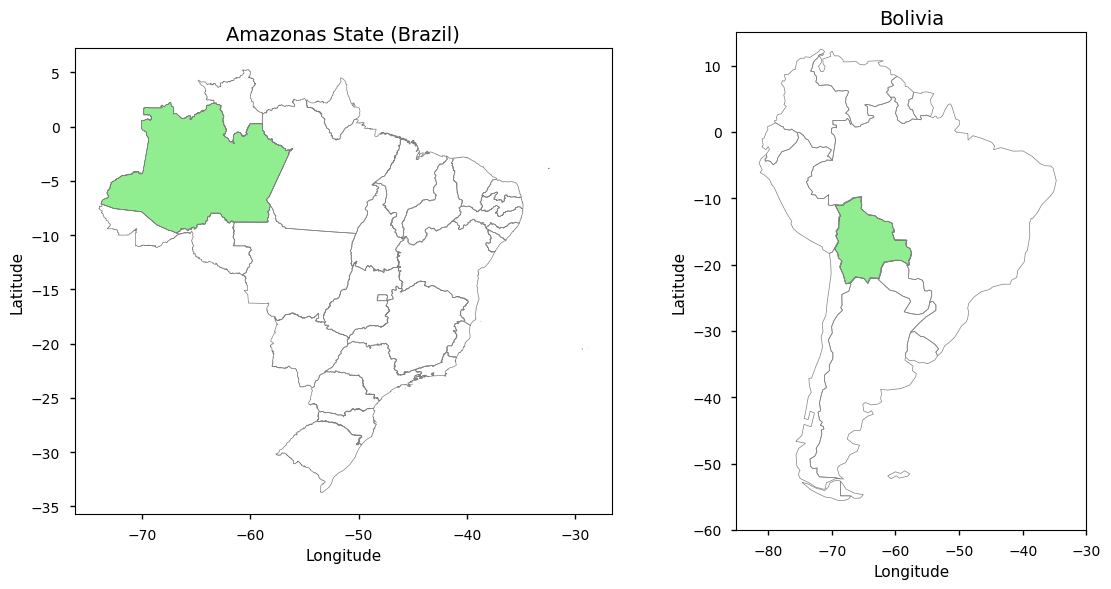

Figure 1.4.1.2. Amazonas State - Brazil (left panel) and Bolivia (right panel).

In [3]:
warnings.filterwarnings("ignore")

# ============================================================
# 1. Amazonas (Brazil) shapefile (IBGE)
# ============================================================

ibge_url = "https://data.humdata.org/dataset/f5f0648e-f085-4c85-8242-26bf6c942f40/resource/2f26be26-a081-4557-8572-58545cd70e9f/download/bra_adm_ibge_2020_shp.zip"

r = requests.get(ibge_url)
with open("bra_adm_ibge_2020.zip", "wb") as f:
    f.write(r.content)

states_gdf = gpd.read_file("zip://bra_adm_ibge_2020.zip!bra_admbnda_adm1_ibge_2020.shp")
states_gdf = states_gdf.set_crs("EPSG:4674").to_crs("EPSG:4326")
amazonas = states_gdf[states_gdf['ADM1_PT'].str.lower() == 'amazonas']

# ============================================================
# 2. Bolivia (Natural Earth)
# ============================================================

ne_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
r = requests.get(ne_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("ne_110m_admin_0_countries")

countries_gdf = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
bolivia = countries_gdf[countries_gdf['NAME'] == 'Bolivia']

# ============================================================
# 3. Plot regions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Amazonas ---
states_gdf.boundary.plot(ax=axes[0], color="gray", linewidth=0.5)
amazonas.plot(ax=axes[0], color="lightgreen", edgecolor="black")
axes[0].set_title("Amazonas State (Brazil)", fontsize=14)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# --- Bolivia ---
sa.boundary.plot(ax=axes[1], color="gray", linewidth=0.5)
bolivia.plot(ax=axes[1], color="lightgreen", edgecolor="black")
axes[1].set_title("Bolivia", fontsize=14)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_xlim(-85, -30)
axes[1].set_ylim(-60, 15)

plt.tight_layout()

plt.show()
display(Markdown("Figure 1.4.1.2. Amazonas State - Brazil (left panel) and Bolivia (right panel)."))

In [4]:
# Define request

request = (
    "satellite-fire-radiative-power",
    {
        "product_type": "gridded",
        "time_aggregation": "month",
        "horizontal_aggregation": "0_25_degree_x_0_25_degree",
        "satellite": ["sentinel_3a", "sentinel_3b"],
        "observation_time": ["day", "night"],
        "year": ["2020", "2021","2022", "2023","2024", "2025"],
        "month": ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"],
        "day": ["01"],
        "version": "1_2",
        },
)




In [5]:
# Download and regionalize
lon_slice = slice(minx, maxx) 
lat_slice = slice(maxy, miny)

ds = download.download_and_transform(
    *request,
    transform_func=utils.regionalise,
    transform_func_kwargs={"lon_slice": lon_slice, "lat_slice": lat_slice},
    chunks={"year": 1},
)

100%|██████████| 6/6 [00:00<00:00, 45.41it/s]


(section-3)=
### 3. Spatial analysis, averaged maps of Fire Radiative Power (FRP) and Active Fire (AF) for each season

To assess the spatial quality of the dataset, seasonal averages of the FRP (in MW) and AF (in pixel counts) were computed for the full period 2020–2025, covering the four meteorological seasons: DJF, MAM, JJA, and SON. The analysis focuses on the Amazon Basin and adjacent regions, encompassing the Amazonas state (Brazil) and Bolivia. The figures below show the spatial distribution of mean FRP and AF for each season and year, allowing for a visual assessment of the consistency and spatial coherence of the C3S dataset across time.

In [6]:
# --- define frp and active fire_pixels ---
frp = ds['frp']
af = ds['fire_pixels']

# --- Add year and season coordinates ---
frp.coords["year"] = frp["time"].dt.year
frp.coords["season"] = frp["time"].dt.season
af.coords["year"] = af["time"].dt.year
af.coords["season"] = af["time"].dt.season

# --- Group by year + season ---
frp_season_year = frp.groupby(["year", "season"]).mean("time")
af_season_year  = af.groupby(["year", "season"]).sum("time")

#### Data completeness and quality flag assessment

Before interpreting the seasonal maps, it is important to assess the spatial 
distribution of observation quality across the study region. Two ancillary 
variables from the dataset are used for this purpose:

- **`atmospheric_condition_flag_pixels`**: number of pixels not processed by the 
Active Fire detection algorithm due to unsuitable atmospheric conditions (e.g. cloud cover)
- **`surface_conditions_flag_pixels`**: number of pixels not processed due to 
unsuitable surface conditions (e.g. permanent water bodies)

Both variables are normalised by `total_pixels` to produce spatially comparable 
fractions between 0 and 1, where higher values indicate a greater proportion of 
pixels affected by each condition. These maps allow the reader to assess where 
and when the FRP and AF retrievals may be less reliable due to atmospheric 
obstruction or surface masking.

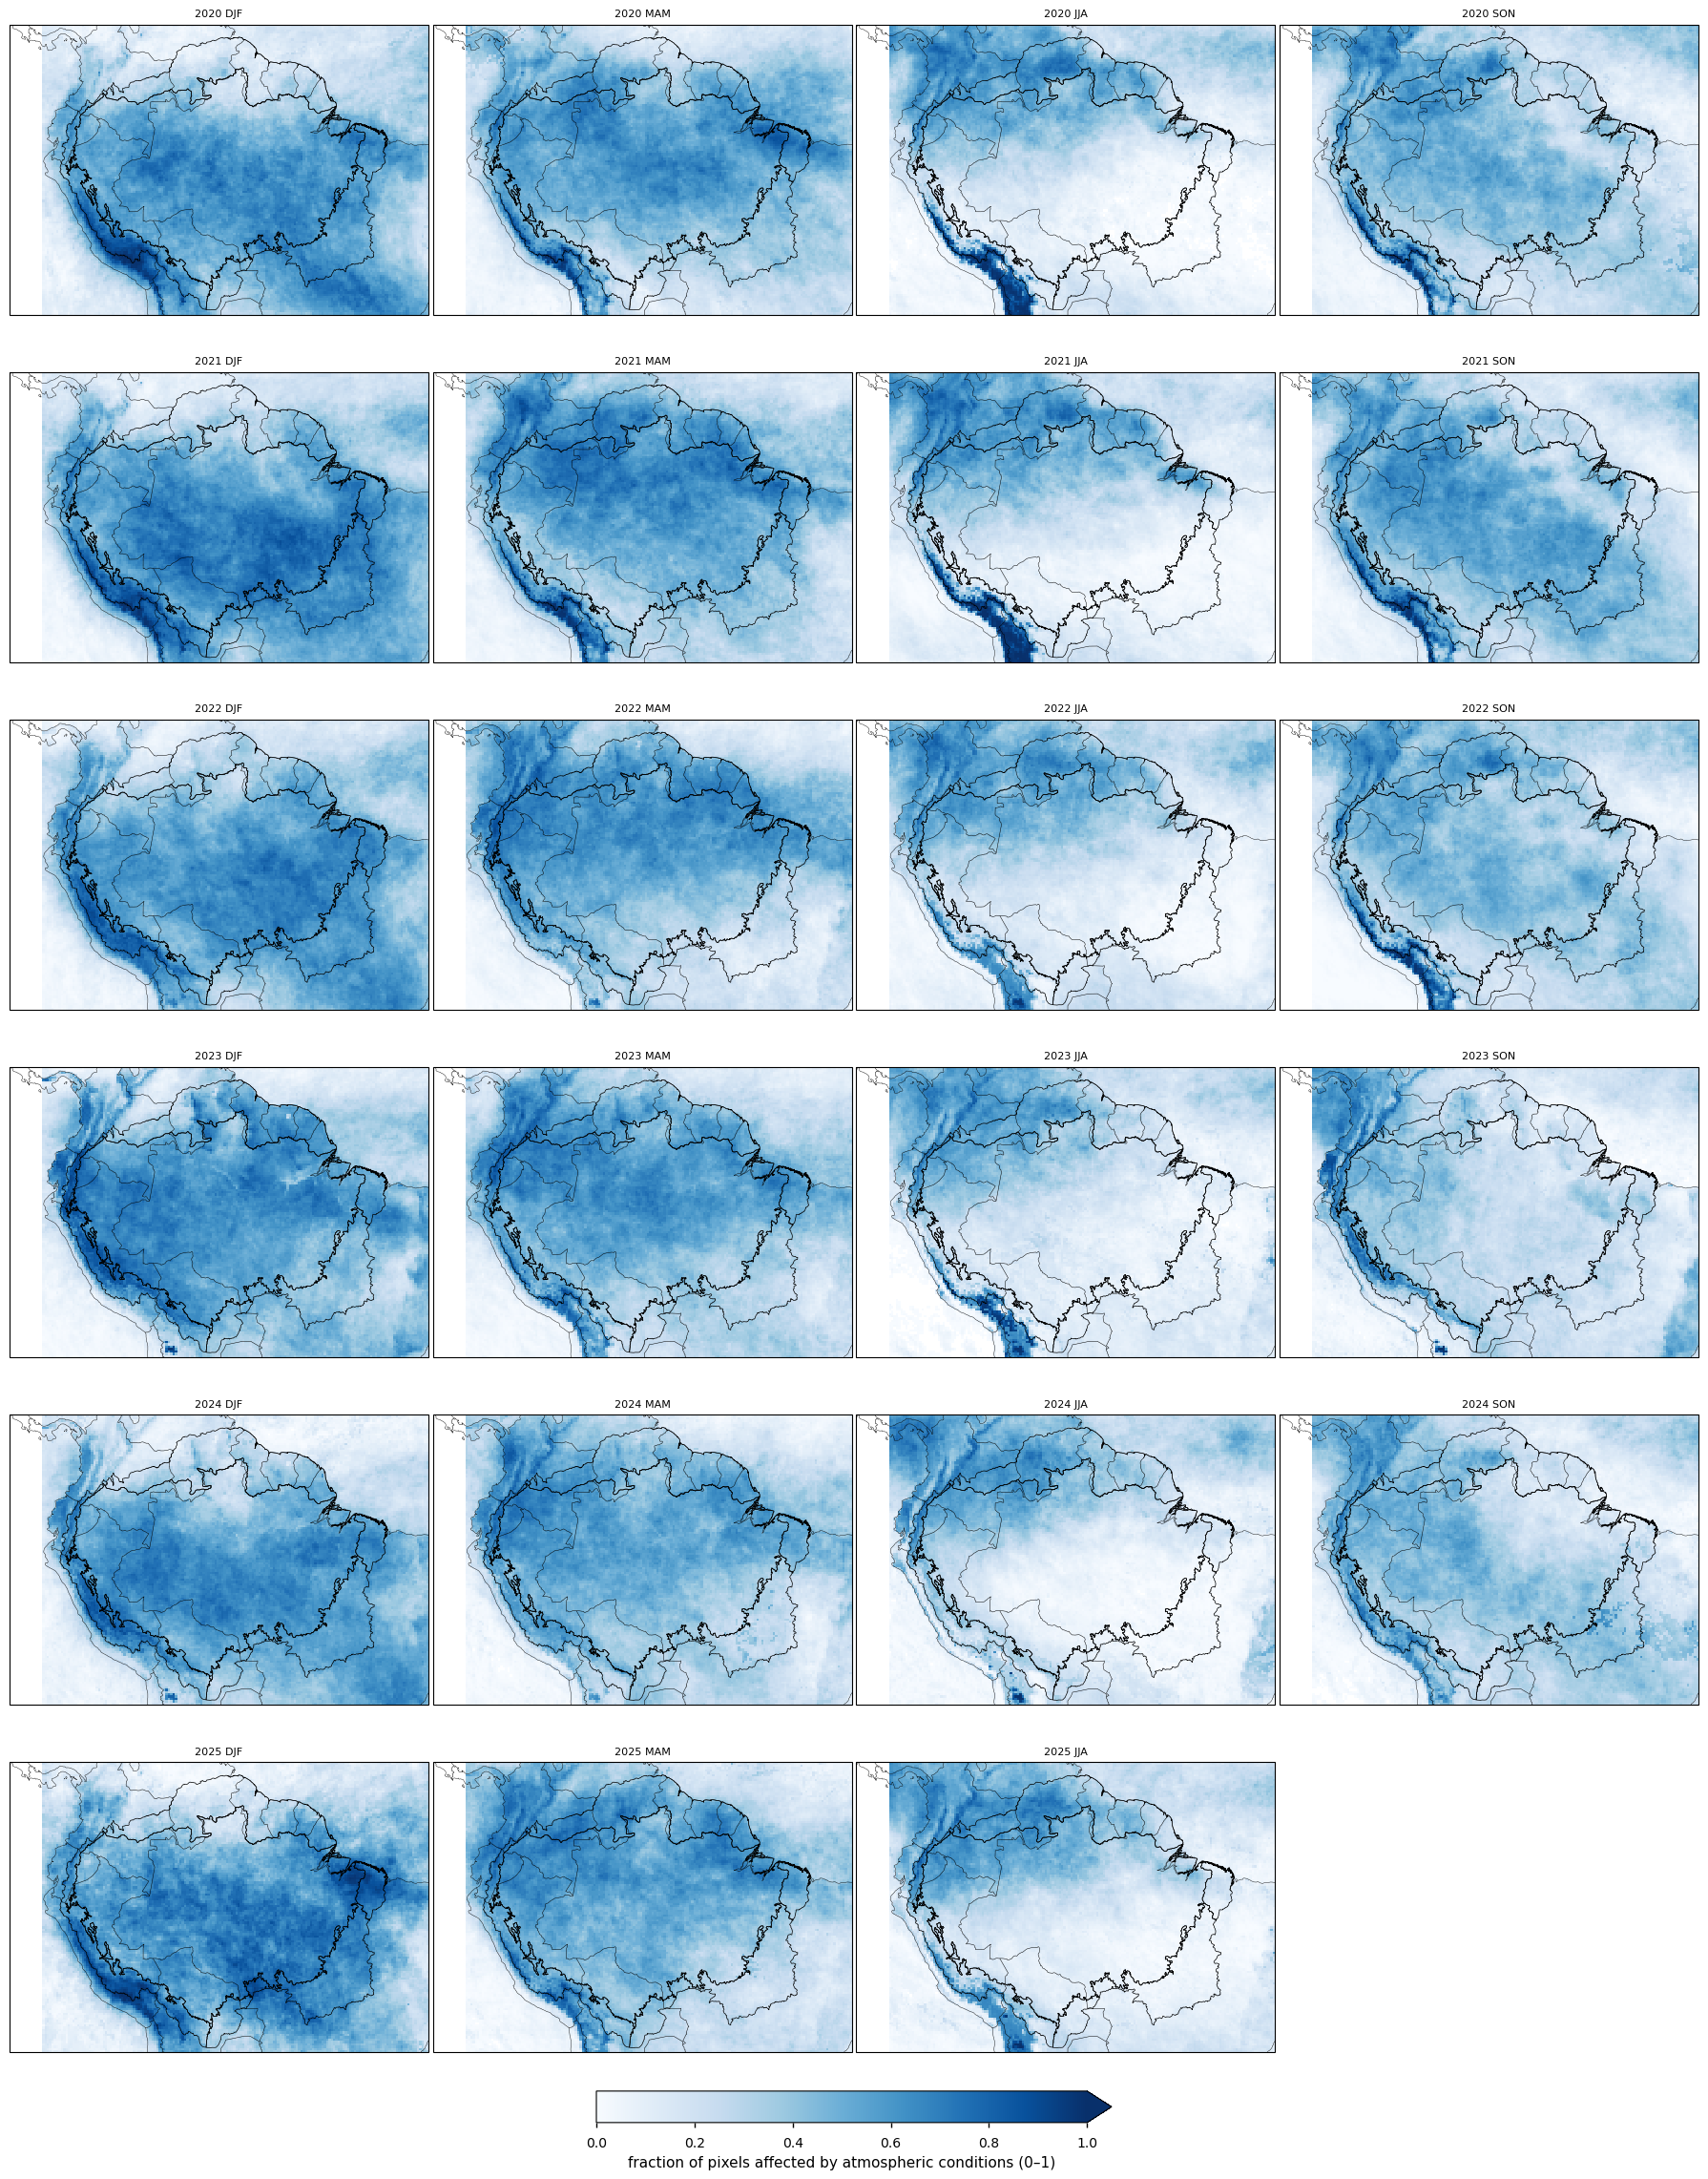

**Figure 1.4.1.3a.** Seasonal fraction of pixels affected by atmospheric conditions (e.g. cloud cover) per grid cell per season between 2020 and 2025. Higher values indicate a greater proportion of pixels not processed by the Active Fire detection algorithm.

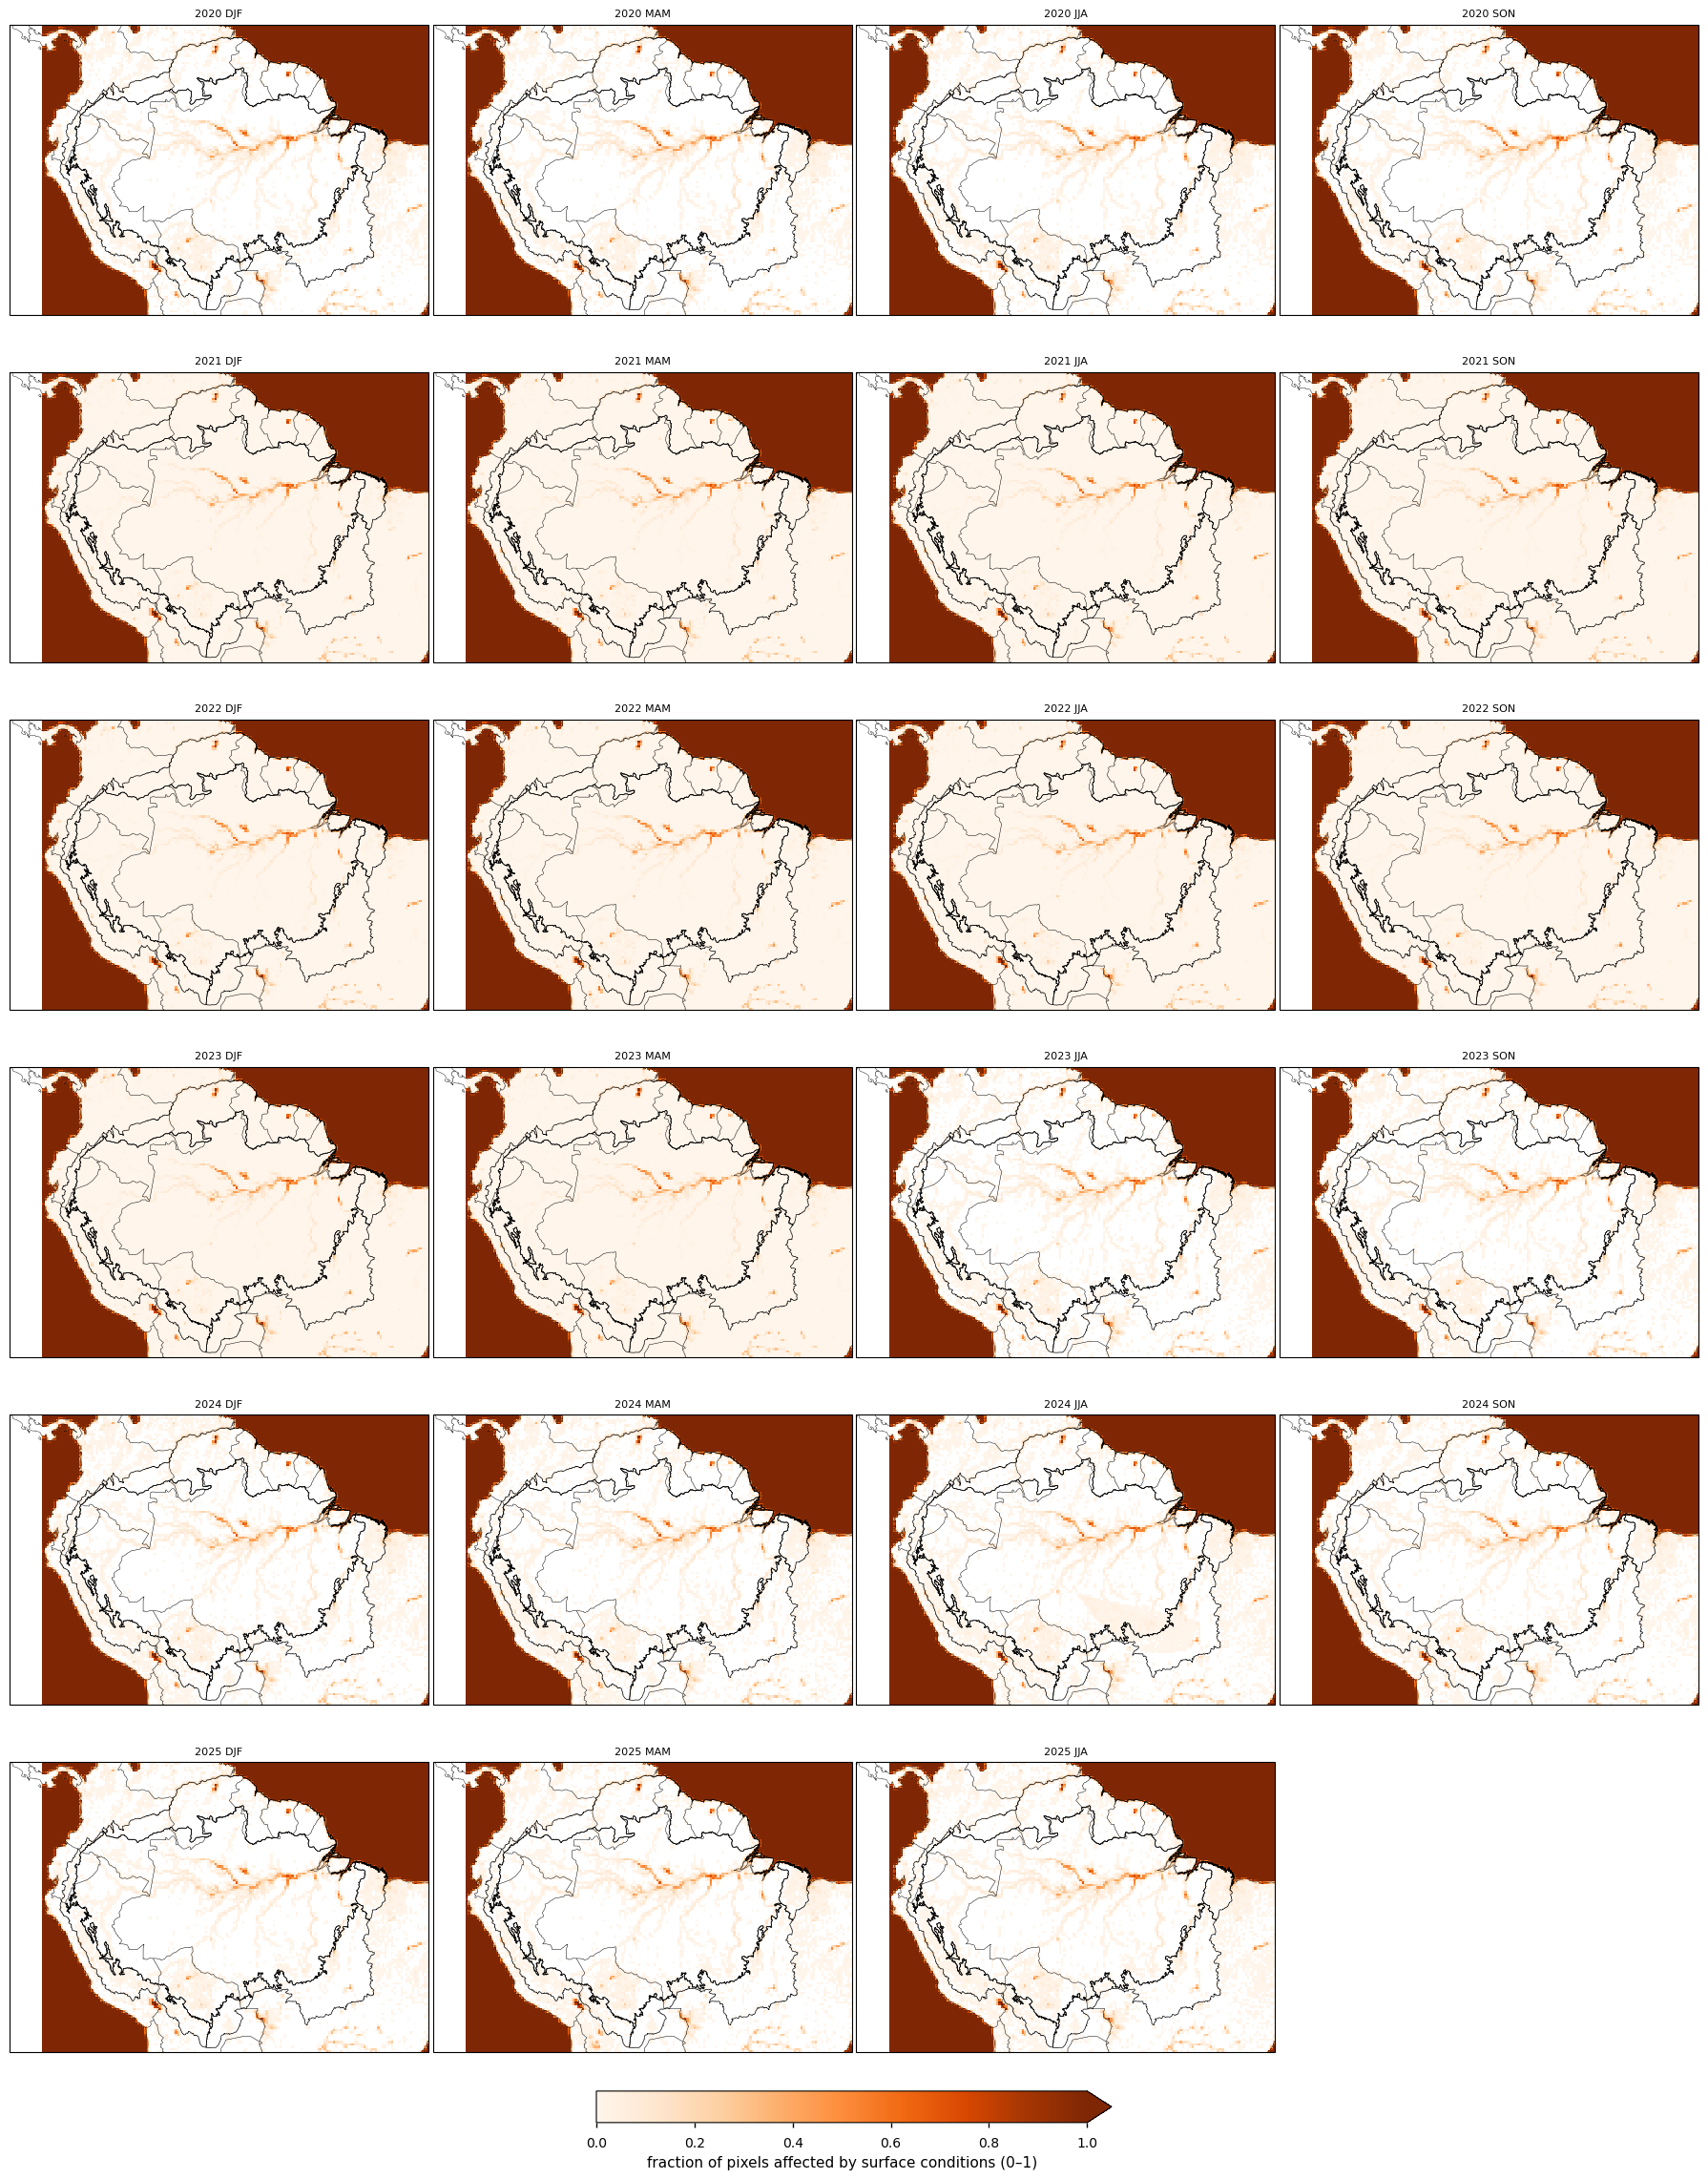

**Figure 1.4.1.3b.** Seasonal fraction of pixels affected by surface conditions (e.g. permanent water bodies) per grid cell per season between 2020 and 2025. Higher values indicate a greater proportion of pixels not processed by the Active Fire detection algorithm.

In [14]:
# ============================================================
# DATA COMPLETENESS ASSESSMENT
# ============================================================

total_pix = ds['total_pixels']
atm_flag  = ds['atmospheric_condition_flag_pixels']
surf_flag = ds['surface_conditions_flag_pixels']

# --- Compute fractions ---
atm_fraction  = atm_flag  / total_pix
surf_fraction = surf_flag / total_pix

seasons_plot = ["DJF", "MAM", "JJA", "SON"]
years_plot = [2020, 2021, 2022, 2023, 2024, 2025]
extent = [-85, -40, -21, 10]

for var, label, cmap, fig_num, fig_desc in [
    (atm_fraction,  'fraction of pixels affected by atmospheric conditions (0–1)', 'Blues',   '1.4.1.3a', 'atmospheric conditions (e.g. cloud cover)'),
    (surf_fraction, 'fraction of pixels affected by surface conditions (0–1)',     'Oranges', '1.4.1.3b', 'surface conditions (e.g. permanent water bodies)')
]:
    var.coords["year"]   = var["time"].dt.year
    var.coords["season"] = var["time"].dt.season

    fig, axes = plt.subplots(
        6, 4, figsize=(18, 22),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    plt.subplots_adjust(wspace=0.05, hspace=0.35)

    for row, year in enumerate(years_plot):
        for col, s in enumerate(seasons_plot):
            ax = axes[row, col]

            da = var.sel(time=var.time.dt.year == year)
            da = da.sel(time=da.time.dt.season == s)

            if da.time.size == 0:
                ax.set_visible(False)
                continue

            da = da.mean("time")
            im = da.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap=cmap, add_colorbar=False,
                         vmin=0, vmax=1)
            ax.set_extent(extent, crs=ccrs.PlateCarree())
            amazon.boundary.plot(ax=ax, color="black", linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.35)
            ax.coastlines()
            ax.set_title(f"{year} {s}", fontsize=8)

    plt.tight_layout()
    cbar_ax = fig.add_axes([0.35, -0.02, 0.3, 0.015])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                 label=label, extend='max')
    plt.show()
    display(Markdown(f"**Figure {fig_num}.** Seasonal fraction of pixels affected by {fig_desc} "
                     f"per grid cell per season between 2020 and 2025. Higher values indicate "
                     f"a greater proportion of pixels not processed by the Active Fire detection algorithm."))

The quality flag maps (Figure 1.4.1.3) reveal distinct spatial and temporal 
patterns in observation quality across the Amazon Basin.

The atmospheric condition fraction (cloud cover) shows clear seasonality — 
higher values are observed during DJF and MAM, particularly over the western 
Amazon and the Andes foothills, reflecting the wet season cloud cover typical 
of these regions. During JJA and SON, atmospheric obstruction is markedly 
reduced, coinciding with the dry season when fire activity is highest. This 
is an important quality consideration: the seasons with the most reliable 
fire detections (JJA and SON) are also the seasons where fire activity is 
most prevalent, supporting the interpretation of the FRP and AF maps.

The surface condition fraction is largely static across years and seasons, 
as expected — it reflects permanent features such as water bodies (notably 
the Amazon river system and floodplains), which are consistently masked by 
the algorithm. This variable does not introduce temporal variability in 
observation quality and can be treated as a fixed land cover mask.

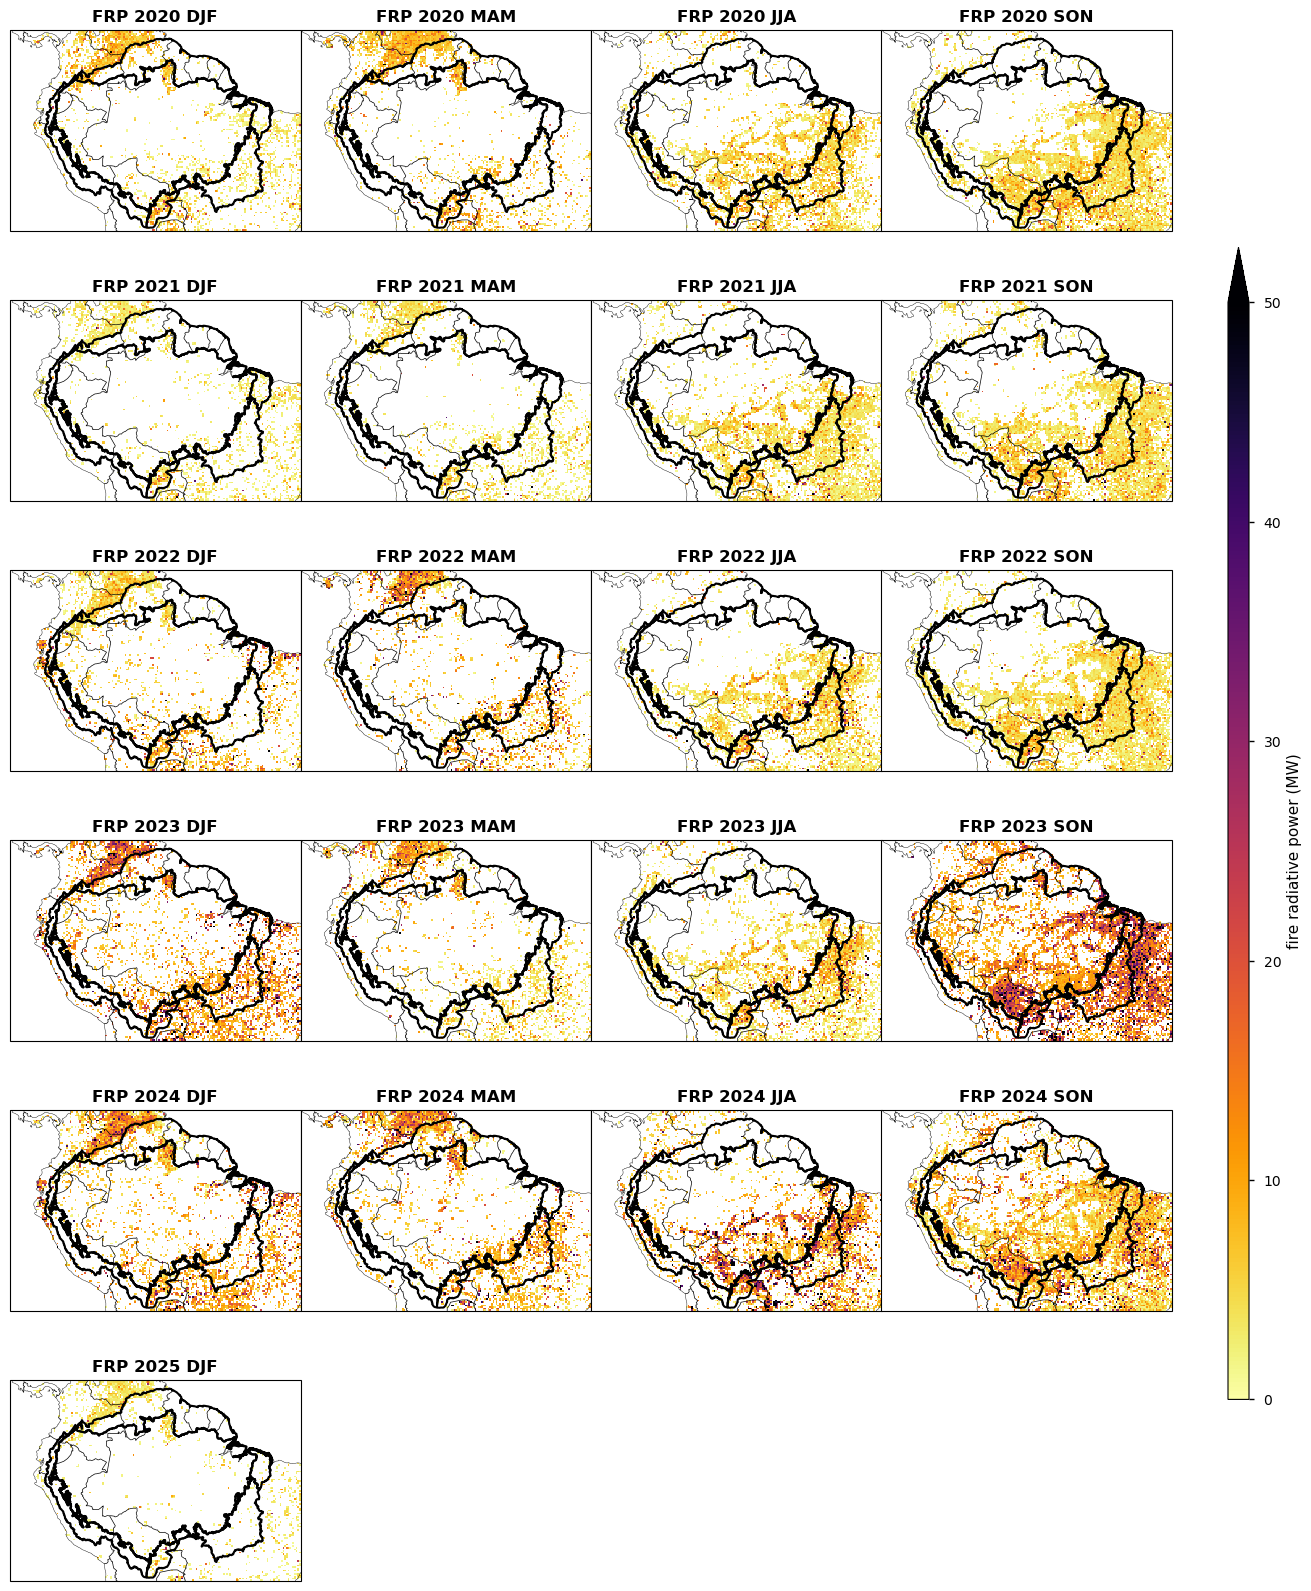

**Figure 1.4.1.4.** Seasonal Fire Radiative Power (FRP) over the Amazon Basin (2020–2025).

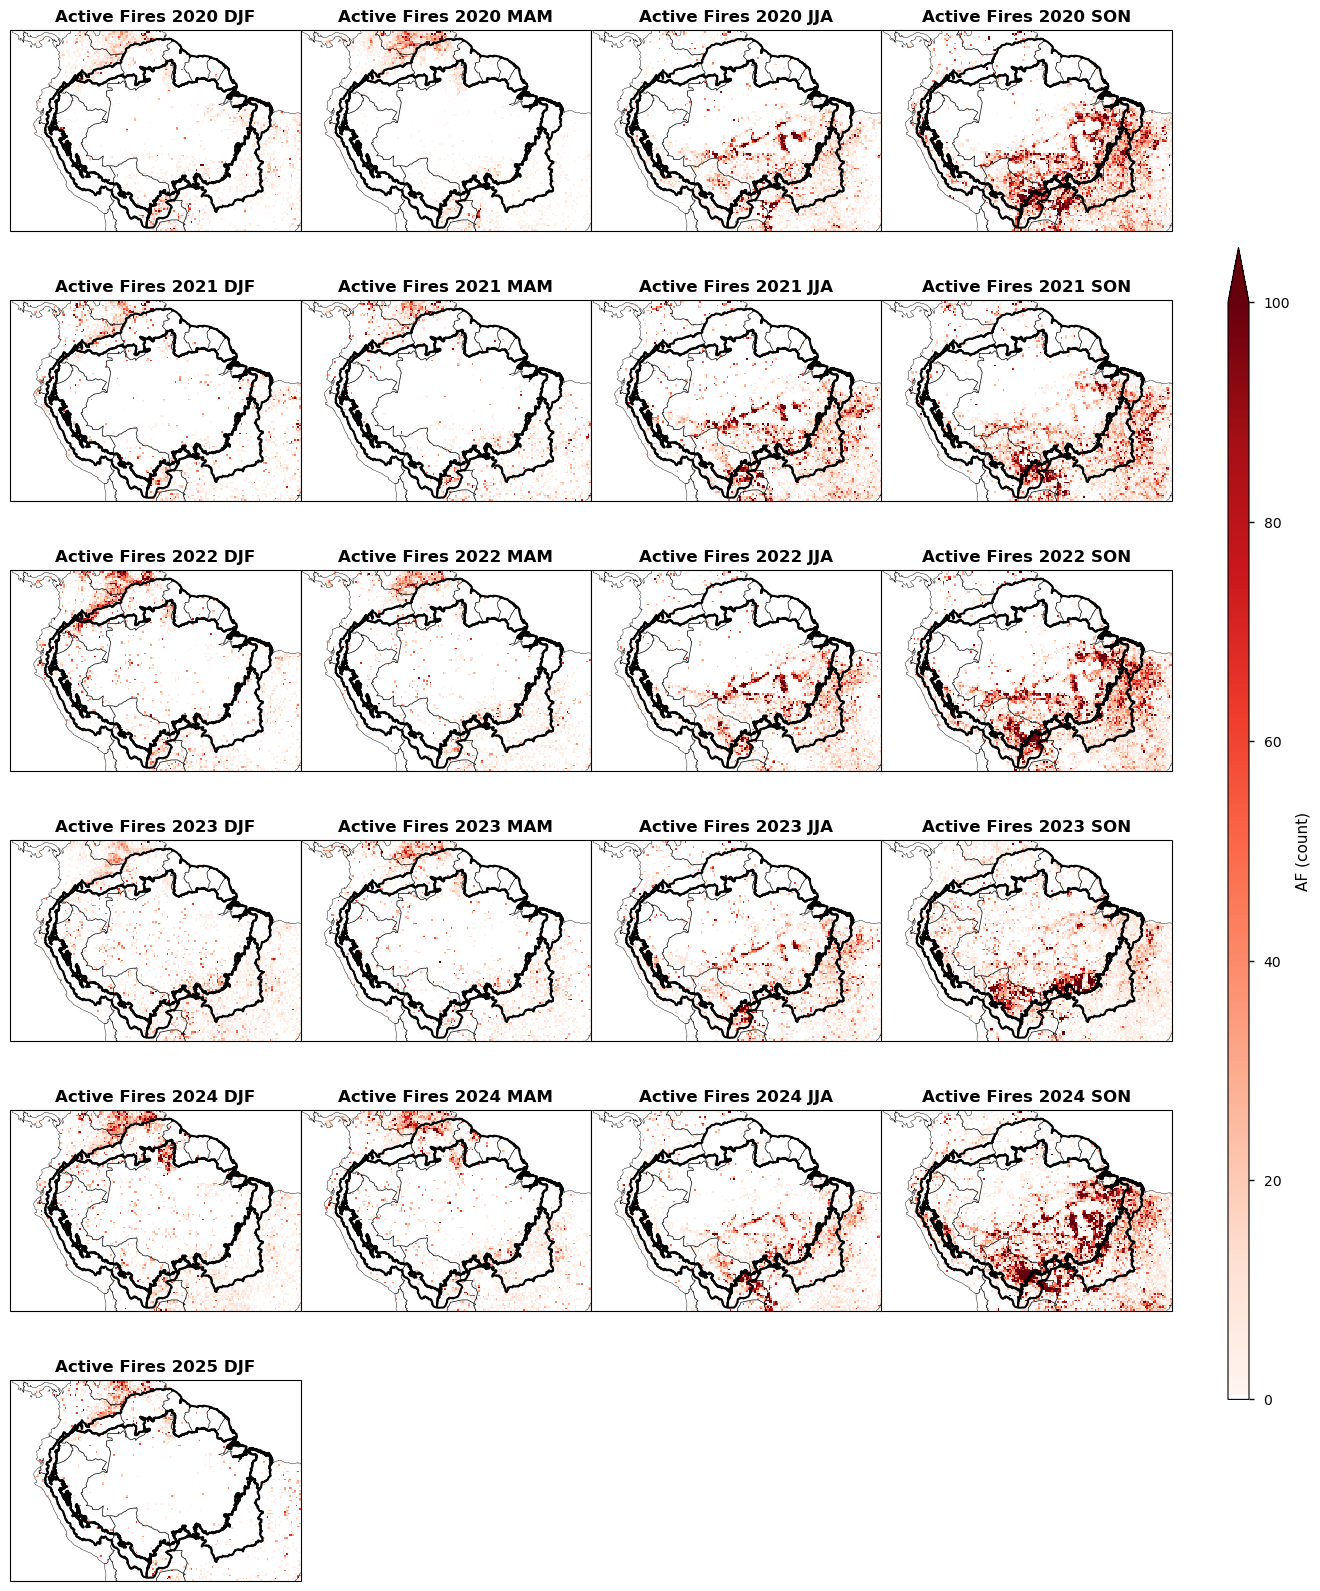

**Figure 1.4.1.5.** Seasonal Active Fires (AF) over the Amazon Basin (2020–2025).

In [8]:
warnings.filterwarnings("ignore")

# --- Seasons and years ---
seasons = ["DJF", "MAM", "JJA", "SON"]
years   = [2020, 2021, 2022, 2023, 2024, 2025]

# --- Geographic extent ---
extent = [-85, -40, -21, 10]   # [lon_min, lon_max, lat_min, lat_max]

# ============================================================
# CUSTOM COLORMAP FOR ative fire: zero → white
# ============================================================
reds = cm.get_cmap("Reds", 256)
reds_colors = reds(np.linspace(0, 1, 256))
reds_colors[0] = np.array([1, 1, 1, 1])  # zero = pure white
Reds_white0 = mcolors.ListedColormap(reds_colors)

# ============================================================
# FUNCTION TO PLOT A VARIABLE
# ============================================================
def plot_variable(var_season_year, cmap, label, title_prefix, vmin=None, vmax=None):

    valid_combinations = [(y, s) for y in years for s in seasons
                          if not (y == 2025 and s in ["MAM", "JJA", "SON"])]

    nrows = len(set([y for y, s in valid_combinations]))
    ncols = len(seasons)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(14, 18),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={'wspace': 0, 'hspace': 0}
    )

    # --- Plot seasonal maps ---
    for row, year in enumerate(years):
        for col, s in enumerate(seasons):

            ax = axes[row, col]

            # Remove invalid 2025 seasons
            if year == 2025 and s in ["MAM", "JJA", "SON"]:
                ax.remove()
                continue

            da = var_season_year.sel(year=year, season=s)

            im = da.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                add_colorbar=False,
                vmin=vmin,
                vmax=vmax
            )

            # --- Set geographic domain ---
            ax.set_extent(extent, crs=ccrs.PlateCarree())

            # --- Overlay boundaries ---
            amazon.boundary.plot(ax=ax, color="black", linewidth=1.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.5)
            ax.coastlines()

            ax.set_title(f"{title_prefix} {year} {s}", fontsize=12, weight="bold")

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.64])
    fig.colorbar(im, cax=cbar_ax, label=label, extend="max")

    # Proper spacing for Cartopy subplots
    fig.subplots_adjust(
        left=0.05, right=0.88, top=0.96, bottom=0.06,
        hspace=0.25, wspace=0.05
    )

    plt.show()

# ============================================================
# PLOT fire radiative power
# ============================================================
plot_variable(
    frp_season_year,
    cmap="inferno_r",
    label="fire radiative power (MW)",
    title_prefix="FRP",
    vmin=0,
    vmax=50
)

display(Markdown("**Figure 1.4.1.4.** Seasonal Fire Radiative Power (FRP) over the Amazon Basin (2020–2025)."))

# ============================================================
# PLOT active fires (with zero = white colormap)
# ============================================================
plot_variable(
    af_season_year,
    cmap=Reds_white0,        # ← custom colormap here
    label="AF (count)",
    title_prefix="Active Fires",
    vmin=0,
    vmax=100
)

display(Markdown("**Figure 1.4.1.5.** Seasonal Active Fires (AF) over the Amazon Basin (2020–2025)."))


The spatial patterns of Fire Radiative Power (FRP) and Active Fires (AF) during 2020–2025 compare well across the seasonal periods of December–January–February (DJF), March–April–May (MAM), June–July–August (JJA), and September–October–November (SON). Fire activity was notably concentrated in the southeastern portion of Amazonia sensu stricto and in the Planalto region, which encompasses the Brazilian Cerrado savanna — an ecosystem naturally characterised by recurrent fire dynamics. A direct comparison of fire severity between regions requires normalisation by area, which is beyond the scope of this assessment; absolute fire pixel counts are therefore not indicative of relative impact between regions of different sizes.

(section-4)=
### 4. Temporal analysis of fire radiative power and active fire

To assess the temporal consistency of the dataset, annual Active Fire (AF) pixel 
counts and 95th percentile Fire Radiative Power (FRP) were computed for two specific 
regions: the Amazonas state (Brazil) and Bolivia, following the methodology described 
in Kelley et al. (2025) [[2]](https://essd.copernicus.org/preprints/essd-2025-483/). 
These regions were selected because they are explicitly referenced in both [[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html) 
and [[2]](https://essd.copernicus.org/preprints/essd-2025-483/) as areas of 
exceptional fire activity during the 2020–2024 period.

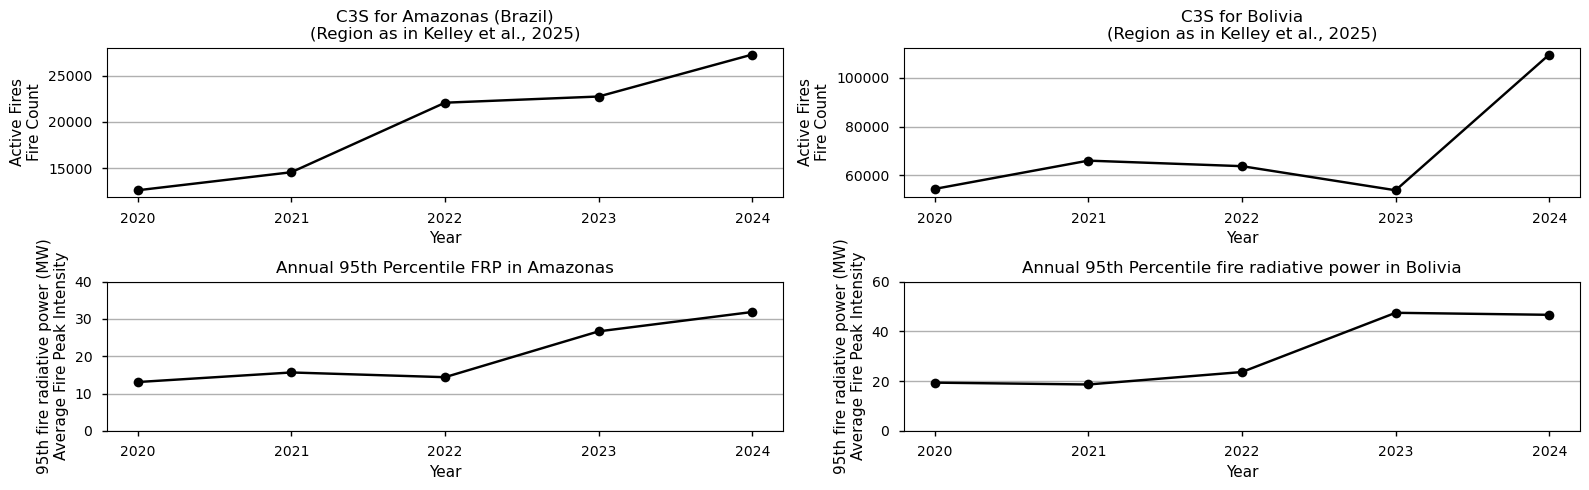

**Figure 1.4.1.6.** Annual Active Fires (AF) and 95th Percentile Fire Radiative Power (FRP) for Amazonas and Bolivia from 2020 to 2024.

In [9]:
# Ignore warnings
warnings.filterwarnings("ignore")

# ============================
# --- Amazonas (Brazil) ---
# ============================
mask_amazonas = regionmask.Regions([amazonas.geometry.values[0]])
frp_amazonas = frp.where(mask_amazonas.mask(frp.longitude, frp.latitude) == 0)
af_amazonas = af.where(mask_amazonas.mask(af.longitude, af.latitude) == 0)

annual_frp_amazonas_percentile = []
years = np.unique(frp_amazonas['time.year'].values)[:5]
for yr in years:
    arr = frp_amazonas.where(frp_amazonas['time.year'] == yr)
    arr_flat = arr.values.flatten()
    arr_flat = arr_flat[~np.isnan(arr_flat)]
    value_95 = np.percentile(arr_flat, 95)
    annual_frp_amazonas_percentile.append({'year': yr, 'peak_frp': value_95})
annual_frp_amazonas_df = pd.DataFrame(annual_frp_amazonas_percentile)

# Monthly active fire time series (sum only over space)
monthly_af_amazonas = af_amazonas.sum(dim=('latitude', 'longitude'))
monthly_af_amazonas = monthly_af_amazonas.sel(time=monthly_af_amazonas.time.dt.year <= 2024)

# Convert to annual if needed for plotting
annual_af_amazonas_df = (monthly_af_amazonas.groupby('time.year')
    .sum()
    .to_dataframe(name='annual_af')
    .reset_index()
)
   
# ============================
# --- Bolivia ---
# ============================
mask_bolivia = regionmask.Regions([bolivia.geometry.values[0]])
frp_bolivia = frp.where(mask_bolivia.mask(frp.longitude, frp.latitude) == 0)
af_bolivia = af.where(mask_bolivia.mask(af.longitude, af.latitude) == 0)

annual_frp_bolivia_percentile = []
years_bolivia = np.unique(frp_bolivia['time.year'].values)[:5]
for yr in years_bolivia:
    arr = frp_bolivia.where(frp_bolivia['time.year'] == yr)
    arr_flat = arr.values.flatten()
    arr_flat = arr_flat[~np.isnan(arr_flat)]
    value_95 = np.percentile(arr_flat, 95)
    annual_frp_bolivia_percentile.append({'year': yr, 'peak_frp': value_95})
annual_frp_bolivia_df = pd.DataFrame(annual_frp_bolivia_percentile)
# Monthly active fire time series (sum only over space)
monthly_af_bolivia = af_bolivia.sum(dim=('latitude', 'longitude')) 
monthly_af_bolivia = monthly_af_bolivia.sel(time=monthly_af_bolivia.time.dt.year <= 2024)
# Convert to annual if needed for plotting
annual_af_bolivia_df = (monthly_af_bolivia.groupby('time.year')
    .sum()
    .to_dataframe(name='annual_af')
    .reset_index()
)   

# ============================
# --- Plotting ---
# ============================
fig, axes = plt.subplots(2, 2, figsize=(16, 5), sharey=False)

# active fires for Amazonas (top left)
axes[0, 0].plot(annual_af_amazonas_df['year'], annual_af_amazonas_df['annual_af'], 'o-k', markersize=7)
axes[0, 0].grid(axis='y')
axes[0, 0].set_xticks(annual_af_amazonas_df['year'])
axes[0, 0].set_xticklabels(annual_af_amazonas_df['year'].astype(int))
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_title("C3S for Amazonas (Brazil)\n(Region as in Kelley et al., 2025)", fontsize=12)
axes[0, 0].set_ylabel('Active Fires\nFire Count')

# active fires for Bolivia (top right)
axes[0, 1].plot(annual_af_bolivia_df['year'], annual_af_bolivia_df['annual_af'], 'o-k', markersize=7)
axes[0, 1].grid(axis='y')
axes[0, 1].set_xticks(annual_af_bolivia_df['year'])
axes[0, 1].set_xticklabels(annual_af_bolivia_df['year'].astype(int))
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_title('C3S for Bolivia\n(Region as in Kelley et al., 2025)', fontsize=12)
axes[0, 1].set_ylabel('Active Fires\nFire Count')

# 95th percentile fire radiative power for Amazonas (bottom left)
axes[1, 0].plot(annual_frp_amazonas_df['year'], annual_frp_amazonas_df['peak_frp'], 'o-k', markersize=7)
axes[1, 0].grid(axis='y')
axes[1, 0].set_xticks(annual_frp_amazonas_df['year'])
axes[1, 0].set_xticklabels(annual_frp_amazonas_df['year'].astype(int))
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_title("Annual 95th Percentile FRP in Amazonas", fontsize=12)
axes[1, 0].set_ylim(0, 30)
axes[1, 0].set_yticks([0, 10, 20, 30, 40])
axes[1, 0].set_ylabel('95th fire radiative power (MW)\nAverage Fire Peak Intensity')

# 95th percentile fire radiative power for Bolivia (bottom right)
axes[1, 1].plot(annual_frp_bolivia_df['year'], annual_frp_bolivia_df['peak_frp'], 'o-k', markersize=7)
axes[1, 1].grid(axis='y')
axes[1, 1].set_xticks(annual_frp_bolivia_df['year'])
axes[1, 1].set_xticklabels(annual_frp_bolivia_df['year'].astype(int))
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_title('Annual 95th Percentile fire radiative power in Bolivia', fontsize=12)
axes[1, 1].set_ylim(0, 60)
axes[1, 1].set_yticks([0, 20, 40, 60])
axes[1, 1].set_ylabel('95th fire radiative power (MW)\nAverage Fire Peak Intensity')

plt.tight_layout()
plt.show()
display(Markdown("**Figure 1.4.1.6.** Annual Active Fires (AF) and 95th Percentile Fire Radiative Power (FRP) for Amazonas and Bolivia from 2020 to 2024."))


In [10]:
print("=== Amazonas — Annual Active Fire counts ===")
for _, row in annual_af_amazonas_df.iterrows():
    print(f"  {int(row['year'])}: {int(row['annual_af']):,} fire pixels")

print(f"\n  Peak year: {int(annual_af_amazonas_df.loc[annual_af_amazonas_df['annual_af'].idxmax(), 'year'])}")
print(f"  Peak-to-base ratio (2024 vs 2020): {annual_af_amazonas_df['annual_af'].max() / annual_af_amazonas_df['annual_af'].min():.1f}x")

print("\n=== Bolivia — Annual Active Fire counts ===")
for _, row in annual_af_bolivia_df.iterrows():
    print(f"  {int(row['year'])}: {int(row['annual_af']):,} fire pixels")

print(f"\n  Peak year: {int(annual_af_bolivia_df.loc[annual_af_bolivia_df['annual_af'].idxmax(), 'year'])}")
print(f"  Peak-to-base ratio (2024 vs 2020): {annual_af_bolivia_df['annual_af'].max() / annual_af_bolivia_df['annual_af'].min():.1f}x")

print("\n=== Amazonas — 95th percentile FRP (MW) ===")
for _, row in annual_frp_amazonas_df.iterrows():
    print(f"  {int(row['year'])}: {row['peak_frp']:.1f} MW")

print("\n=== Bolivia — 95th percentile FRP (MW) ===")
for _, row in annual_frp_bolivia_df.iterrows():
    print(f"  {int(row['year'])}: {row['peak_frp']:.1f} MW")

=== Amazonas — Annual Active Fire counts ===
  2020: 12,594 fire pixels
  2021: 14,549 fire pixels
  2022: 22,086 fire pixels
  2023: 22,756 fire pixels
  2024: 27,308 fire pixels

  Peak year: 2024
  Peak-to-base ratio (2024 vs 2020): 2.2x

=== Bolivia — Annual Active Fire counts ===
  2020: 54,421 fire pixels
  2021: 66,033 fire pixels
  2022: 63,762 fire pixels
  2023: 53,872 fire pixels
  2024: 109,570 fire pixels

  Peak year: 2024
  Peak-to-base ratio (2024 vs 2020): 2.0x

=== Amazonas — 95th percentile FRP (MW) ===
  2020: 13.1 MW
  2021: 15.6 MW
  2022: 14.4 MW
  2023: 26.7 MW
  2024: 31.8 MW

=== Bolivia — 95th percentile FRP (MW) ===
  2020: 19.4 MW
  2021: 18.6 MW
  2022: 23.6 MW
  2023: 47.4 MW
  2024: 46.6 MW


For Amazonas (Brazil), C3S records annual Active Fire (AF) pixel counts increasing 
from 12,594 in 2020 to a peak of 27,308 in 2024 a 2.2x increase over the period. 
The 95th percentile FRP also increased steadily, from 13.1 MW in 2020 to 31.8 MW 
in 2024, with a notable increase from 2022 onwards. For Bolivia, annual AF 
counts peaked in 2024 at 109,570 fire pixels 2.0x the 2020 value of 54,421
with the secondary peak in 2022 (63,762) and a marked decrease in 2023 (53,872). 
The 95th percentile FRP in Bolivia peaked in 2023 at 47.4 MW, compared to 19.4 MW 
in 2020, suggesting that while 2024 had the highest fire counts, 2023 was 
characterised by fewer, but more intense fires.

These magnitudes are substantially higher than those reported by Kelley et al. 
(2025) for the same regions, and it is used here as a reference for direct comparison 
with the C3S results shown above 
(see Figures A4 and A5 in [[2]](https://essd.copernicus.org/preprints/essd-2025-483/).). 
Approximately 10–20x higher for AF pixel counts
which is expected given the finer spatial resolution of the C3S dataset (0.1° daily, 
0.25° monthly) compared to the reference, and its sensitivity to smaller and 
shorter-duration fire events. Despite this difference in absolute magnitude, both 
datasets consistently identify 2022 and 2024 as years of elevated fire activity 
in both regions, supporting the temporal consistency of the C3S dataset.

It should be noted that the AF pixel counts and FRP metrics used here are not 
directly comparable to those in Kelley et al. (2025), as the reference uses 
different aggregation methods and sensor characteristics. The comparison should 
therefore be interpreted qualitatively rather than quantitatively.

(section-5)=
### 5. Daily temporal peak of active fire

In this analysis, we use daily Active Fire (AF) observations from the Copernicus Climate Data Store (C3S) for the period July 2023 to December 2024.
The assessment focuses on the Western Amazonia region, defined by the bounding coordinates 2.25° N, −56.00° E and −9.75° S, −77.75° W.
This area encompasses parts of Amazonas (Brazil), Loreto (Peru), and La Paz and Beni (Bolivia), which collectively experienced exceptional fire activity during 2023–2024, as documented by: [[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html).

In [11]:
# Define new request for daily data

request = (
    "satellite-fire-radiative-power",
    {
        "product_type": "gridded",
        "time_aggregation": "day",
        "horizontal_aggregation": "0_1_degree_x_0_1_degree",
        "satellite": ["sentinel_3a", "sentinel_3b"],
        "observation_time": ["night", "day"],
        "year": ["2023"],
        "month": ["06", "07", "08", "09", "10", "11", "12"],
        "day": ["01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"],
        "version": "1_2",
        },
)


In [12]:
# Download and regionalize
ds = download.download_and_transform(
    *request,
    transform_func=utils.regionalise,
    transform_func_kwargs={"lon_slice": lon_slice, "lat_slice": lat_slice},
    chunks={"satellite": 1, "month": 1},
)

100%|██████████| 14/14 [00:00<00:00, 96.43it/s]


In [13]:
print(ds)

<xarray.Dataset> Size: 3GB
Dimensions:                            (time: 214, latitude: 680,
                                        longitude: 467, bounds: 2)
Coordinates:
  * time                               (time) datetime64[ns] 2kB 2023-06-01 ....
  * latitude                           (latitude) float32 3kB 12.35 ... -55.55
  * longitude                          (longitude) float32 2kB -81.35 ... -34.75
    lon_bounds                         (longitude, bounds) float32 4kB dask.array<chunksize=(467, 2), meta=np.ndarray>
    lat_bounds                         (latitude, bounds) float32 5kB dask.array<chunksize=(680, 2), meta=np.ndarray>
    time_bounds                        (time, bounds) datetime64[ns] 3kB dask.array<chunksize=(30, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    fire_pixels                        (time, latitude, longitude) float64 544MB dask.array<chunksize=(15, 340, 234), meta=np.ndarray>
    frp                                

In [14]:
# --- define active fire_pixels ---
af_daily = ds['fire_pixels']

# Select the region slice (already done)
af_daily_region = af_daily.sel(
    latitude=slice(2.25, -9.75),
    longitude=slice(-77.75, -56.00)
)

# Sum over latitude and longitude for daily fire pixel counts
daily_fire_count = af_daily_region.sum(dim=['latitude', 'longitude'])

# Convert to pandas Series for easier sorting
daily_fire_vals = daily_fire_count.compute().to_series()

# Get the top 5 peaks with their counts
top5_peaks = daily_fire_vals.nlargest(5)

# Print the results
print("Top 5 fire peak days in Western Amazonia:")
for rank, (date, count) in enumerate(top5_peaks.items(), start=1):
    print(f"{rank} - Date: {date} - Peak fire pixels: {int(count)}")


Top 5 fire peak days in Western Amazonia:
1 - Date: 2023-09-05 00:00:00 - Peak fire pixels: 1220
2 - Date: 2023-09-27 00:00:00 - Peak fire pixels: 869
3 - Date: 2023-09-08 00:00:00 - Peak fire pixels: 828
4 - Date: 2023-08-26 00:00:00 - Peak fire pixels: 685
5 - Date: 2023-09-07 00:00:00 - Peak fire pixels: 642


The daily C3S data showed significantly higher values of active fire (AF) peaks in Western Amazonia compared to Jones, Matthew W., et al. State of Wildfires 2023–2024. The referenced value of 824 (See Fig.7 in [[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html)) fire pixels within the first 10 days of the same month, indicating that the C3S data exhibits higher peak intensities of active fires in this region. This difference may reflect improved detection sensitivity or increased fire activity since the reference period.

(section-6)=
### 6. Main Takeaways

* [](section-1) The C3S FRP dataset shows spatially coherent seasonal patterns of fire activity 
across the Amazon Basin for 2020–2025, with the highest activity consistently 
concentrated in southeastern Amazonia and Bolivia during the JJA and SON seasons.

* [](section-2) Annual Active Fire (AF) pixel counts increased substantially over the period in 
both regions: from 12,594 to 27,308 fire pixels in Amazonas (2.2x increase), and 
from 54,421 to 109,570 fire pixels in Bolivia (2.0x increase). The 95th percentile 
FRP peaked at 31.8 MW in Amazonas (2024) and 47.4 MW in Bolivia (2023), indicating 
a trend of increasing fire intensity over the period.

* [](section-3) Both the C3S dataset and the State of Wildfires reference (Kelley et al., 2025) 
consistently identify 2022 and 2024 as years of elevated fire activity in Amazonas 
and Bolivia, supporting the temporal consistency of the C3S dataset. The C3S records 
substantially higher AF pixel counts (~10–20x) than the reference, which is expected 
given its finer spatial resolution and sensitivity to smaller fire events.

* [](section-4) Daily C3S data for Western Amazonia identified a peak of 1,220 active fire pixels 
on a single day in early September 2023, compared to 824 fire pixels reported by Jones 
et al. (2024) for the same region (Check Fig.7), consistent with the higher detection sensitivity 
of the C3S dataset.

* [](section-5) Observation quality flags reveal that atmospheric obstruction (cloud cover) is 
highest during DJF and MAM and lowest during JJA and SON (i.e. the seasons with the 
highest fire activity) supporting the reliability of fire detections during the 
most critical periods. Surface condition flags are static and reflect permanent 
land cover features, introducing no temporal variability in observation quality.

* [](section-6) The short length of the C3S time series (5 years, 2020–2025) precludes the 
computation of climatologically meaningful standardised anomalies. This is a key 
limitation of the dataset at its current stage, and robust anomaly analysis will only 
become feasible as the record lengthens.


## ℹ️ If you want to know more

### Key resources

Some key resources and further reading were linked throughout this assessment.

**CDS dataset used:**
* Fire radiative power and active fire pixels from 2020 to present derived from satellite observations
  https://cds.climate.copernicus.eu/datasets/satellite-fire-radiative-power?tab=overview

**Technical documentation:**
* FRP dataset Product User Guide - NIGHTTIME (PUG):
  https://dast.copernicus-climate.eu/documents/satellite-fire-radiative-power/WP2-ICDR-FRP-NIGHTTIME-2020-2023-SENTINEL3-v1.2_PUGS_v3.1_final.pdf

**Wildfire monitoring resources:**
* Copernicus Climate Change Service — State of Climate: Wildfires 2024:
  https://climate.copernicus.eu/esotc/2024/wildfires

* Global Wildfire Information System (GWIS) — near-real-time fire monitoring:
  https://gwis.jrc.ec.europa.eu/

* NASA FIRMS (Fire Information for Resource Management System) — active fire data:
  https://firms.modaps.eosdis.nasa.gov/

* EFFIS (European Forest Fire Information System):
  https://effis.jrc.ec.europa.eu/

**Amazon Basin definition:**
* Amazon basin regions and definition (JRC):
  https://publications.jrc.ec.europa.eu/repository/handle/JRC68635

**Code library used:**
* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`, prepared by [B-Open](https://www.bopen.eu/)

### References

[[1]](https://essd.copernicus.org/articles/16/3601/2024/essd-16-3601-2024-discussion.html) Jones, Matthew W., Douglas I. Kelley, Chantelle A. Burton, et al. 2024. "State of Wildfires 2023–2024." Earth System Science Data 16 (8): 3601–85. https://doi.org/10.5194/essd-16-3601-2024

[[2]](https://essd.copernicus.org/preprints/essd-2025-483/) Kelley, Douglas I., Chantelle Burton, Francesca Di Giuseppe, et al. 2025. "State of Wildfires 2024–25." Earth System Science Data Discussions. https://doi.org/10.5194/essd-2025-483